https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import nltk
from nltk.probability import FreqDist
import re


In [2]:
# Load the dataset
fake_df = pd.read_csv('./Data/raw/Fake.csv')
true_df = pd.read_csv('./Data/raw/True.csv')

In [3]:
fake_df.shape, true_df.shape

((23481, 4), (21417, 4))

In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake_df['subject'].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

In [7]:
true_df['subject'].value_counts()

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

### Phân tích thống kê văn bản (Text EDA)

#### a) Tính và vẽ phân phối độ dài văn bản (số từ, số ký tự) theo nhãn lớp. Kiểm định Mann-Whitney U test để xác định liệu các lớp có sự khác biệt đáng kể về độ dài không.

In [8]:
fake_df['label'] = 0
true_df['label'] = 1

In [9]:
# Combine the datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

In [10]:
# Ensure 'text' column is of type string and remove empty entries

df['text'] = df['text'].astype(str)
df = df[df['text'].str.strip() != '']

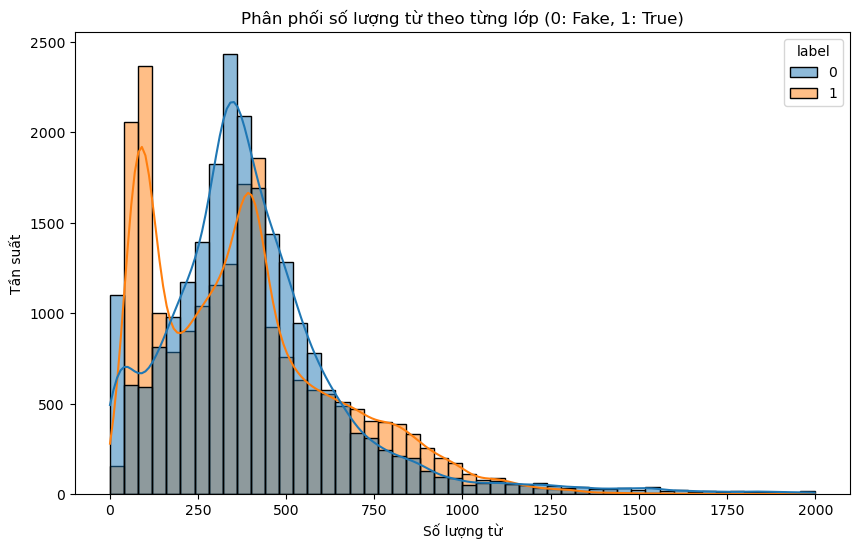

In [11]:
# Tính số ký tự và số từ
df['char_count'] = df['text'].apply(len)
# Tách từ cơ bản bằng khoảng trắng để tối ưu tốc độ cho DataFrame lớn
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
# Lọc bỏ các bài quá dài (> 2000 từ) để biểu đồ không bị nhiễu do outlier
sns.histplot(data=df[df['word_count'] < 2000], x='word_count', hue='label', bins=50, kde=True)
plt.title('Phân phối số lượng từ theo từng lớp (0: Fake, 1: True)')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')
plt.show();

Biểu đồ "Phân phối số lượng từ theo từng lớp (0: Fake, 1: True)" trực quan hóa sự khác biệt về chiều dài bài viết giữa hai nhóm tin tức:

* **Hình dáng phân phối (Distribution Shape):** Cả hai lớp dữ liệu đều có dạng phân phối lệch phải (right-skewed), nghĩa là phần lớn các bài báo có độ dài ngắn đến trung bình (từ 0 đến khoảng 1000 từ), và số lượng bài báo dài giảm dần về phía đuôi (long tail).
* **Đặc điểm lớp Tin Thật (Label 1 - Màu cam):**
    * Phân phối có dạng đa đỉnh (bimodal) rõ rệt.
    * Đỉnh thứ nhất rất cao và nhọn, nằm ở khoảng độ dài rất ngắn (dưới 200 từ). Điều này cho thấy có một lượng lớn tin thật là các bản tin vắn, tin nhanh, hoặc thông báo ngắn.
    * Đỉnh thứ hai thấp hơn, trải rộng ở khoảng 350 - 500 từ, tương ứng với các bài báo thông thường.
* **Đặc điểm lớp Tin Giả (Label 0 - Màu xanh):**
    * Phân phối có xu hướng tập trung thành một đỉnh chính lớn (unimodal) nằm ở khoảng 350 - 450 từ.
    * Khác với tin thật, tin giả ít xuất hiện ở dạng tin quá ngắn (dưới 100 từ) mà thường có một độ dài "tiêu chuẩn" nhất định để đủ không gian xây dựng câu chuyện hoặc lan truyền thông tin sai lệch.
* **Vùng chồng lấn (Overlap):** Mặc dù có sự khác biệt về hình dáng đỉnh, hai phân phối vẫn có sự chồng lấn đáng kể ở đoạn giữa (độ dài từ 250 - 750 từ).

In [12]:
from scipy.stats import mannwhitneyu

# Kiểm định Mann-Whitney U test
words_fake = df[df['label'] == 0]['word_count']
words_real = df[df['label'] == 1]['word_count']

stat, p_value = mannwhitneyu(words_fake, words_real, alternative='two-sided')
print(f'Thống kê Mann-Whitney U: {stat}')
print(f'p-value: {p_value}')

if p_value < 0.05:
    print("-> Có sự khác biệt có ý nghĩa thống kê về độ dài văn bản giữa 2 lớp.")
else:
    print("-> Không có sự khác biệt đáng kể.")

Thống kê Mann-Whitney U: 261411790.5
p-value: 1.461830205893432e-35
-> Có sự khác biệt có ý nghĩa thống kê về độ dài văn bản giữa 2 lớp.


* **Kết quả:**
    * Thống kê U: 261,411,790.5
    * p-value: $1.46 \times 10^{-35}$
* **Kết luận:**
    * Vì p-value cực kỳ nhỏ (nhỏ hơn rất nhiều so với mức ý nghĩa tiêu chuẩn $\alpha = 0.05$), ta có đủ bằng chứng thống kê để bác bỏ giả thuyết vô hiệu ($H_0$).
    * Điều này khẳng định: **Có sự khác biệt có ý nghĩa thống kê về mặt độ dài văn bản giữa nhóm Tin Giả và nhóm Tin Thật.**
    * *Hàm ý cho mô hình:* Độ dài văn bản (số lượng từ) là một đặc trưng (feature) có giá trị phân biệt. Việc đưa thuộc tính này vào làm input cho các mô hình học máy (như Logistic Regression, Random Forest) có thể đóng góp vào việc tăng cường hiệu năng phân loại.

---

#### b) Vẽ word cloud và bảng top-50 từ phổ biến nhất theo từng lớp. Tính type-token ratio (TTR) để đánh giá độ phong phú từ vựng.


--- ĐANG PHÂN TÍCH: Fake News ---
Tổng số Tokens: 9937110
Tổng số Types: 293553
Type-Token Ratio: 0.029541

Top 50 từ phổ biến nhất:
'the': 483203
'to': 286028
'of': 233193
'and': 213059
'a': 202870
'in': 152840
'that': 138416
's': 127621
'is': 105555
'for': 88389
'on': 76951
'was': 66430
'Trump': 64844
'he': 62175
'with': 60672
'his': 55840
'it': 53935
'as': 51541
'be': 47483
'by': 45791
'have': 45252
'are': 44469
'I': 42453
'has': 41777
'not': 41032
'this': 41024
'who': 40634
'The': 40127
't': 39421
'from': 39393
'at': 38276
'they': 37006
'an': 33976
'about': 31681
'you': 30418
'their': 29577
'we': 26261
'or': 23523
'her': 23391
'but': 23226
'will': 23083
'would': 23024
'been': 22734
'people': 21266
'were': 21241
'said': 21112
'she': 20339
'all': 20336
'out': 20219
'what': 20123


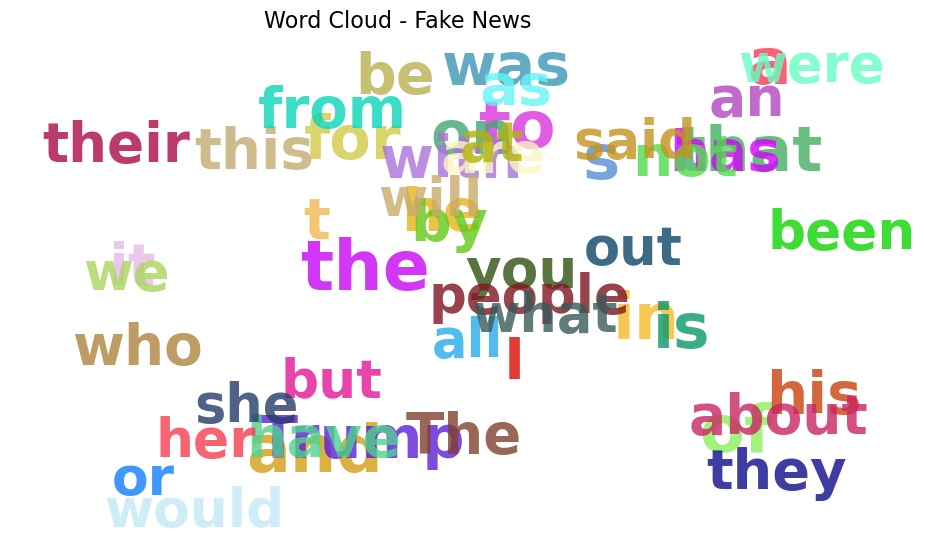


--- ĐANG PHÂN TÍCH: True News ---
Tổng số Tokens: 8259254
Tổng số Types: 178503
Type-Token Ratio: 0.021612

Top 50 từ phổ biến nhất:
'the': 422622
'to': 243787
'of': 204339
'a': 187214
'and': 179411
'in': 169538
'on': 104807
'that': 82512
'for': 77867
'said': 72025
'The': 55109
'is': 54454
'with': 53018
'was': 47741
'by': 46908
'has': 46016
'as': 45182
's': 44638
'he': 43493
'from': 38954
'U.S.': 38271
'Trump': 36461
'his': 36218
'have': 36162
'not': 35179
'it': 33923
'be': 33909
'would': 31330
'an': 31225
'-': 31059
'at': 30898
'who': 27242
'are': 25778
'had': 25568
'will': 24802
'said.': 21582
'(Reuters)': 21239
'its': 20966
'which': 20691
'been': 19540
'were': 18791
'but': 18128
'after': 17841
'they': 17784
'President': 17112
'about': 16791
'their': 16490
'this': 16062
'more': 15812
'also': 15703


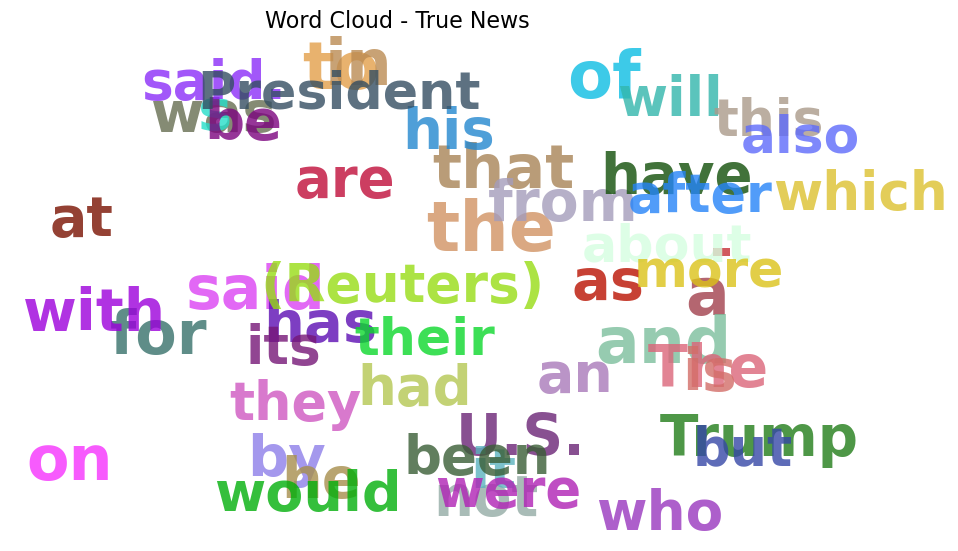

In [13]:
def analyze_text_and_pseudo_wordcloud(text_series, label_name):
    print(f"\n--- ĐANG PHÂN TÍCH: {label_name} ---")
    
    # Gộp text và tách từ (Tokenize)
    all_text = " ".join(text_series.tolist())
    tokens = all_text.split()
    
    # Đếm tần suất bằng NLTK
    freq_dist = FreqDist(tokens)
    top_50 = freq_dist.most_common(50)
    
    # 1. Tính Type-Token Ratio (TTR)
    types = len(freq_dist.keys())
    total_tokens = freq_dist.N()
    ttr = types / total_tokens if total_tokens > 0 else 0
    
    print(f"Tổng số Tokens: {total_tokens}")
    print(f"Tổng số Types: {types}")
    print(f"Type-Token Ratio: {ttr:.6f}")
    
    print(f"\nTop 50 từ phổ biến nhất:")
    for word, count in top_50[:]:
        print(f"'{word}': {count}")
        
    # 2. Vẽ "Word Cloud" bằng matplotlib
    plt.figure(figsize=(10, 6))
    
    # Tìm tần suất lớn nhất để scale font size
    max_freq = top_50[0][1]
    
    for word, freq in top_50:
        # Vị trí ngẫu nhiên
        x, y = np.random.rand(), np.random.rand()
        # Scale font size theo log của tần suất để chữ không bị khổng lồ
        font_size = max(10, (np.log(freq) / np.log(max_freq)) * 50)
        
        plt.text(x, y, word, fontsize=font_size, 
                 color=np.random.rand(3,), alpha=0.8, weight='bold')
        
    plt.axis('off')
    plt.title(f'Word Cloud - {label_name}', fontsize=16, pad= 30)
    plt.show()
    
    return freq_dist

# Chạy cho cả 2 lớp
freq_fake = analyze_text_and_pseudo_wordcloud(df[df['label'] == 0]['text'], "Fake News")
freq_real = analyze_text_and_pseudo_wordcloud(df[df['label'] == 1]['text'], "True News")

Dựa vào việc quan sát trực quan hai biểu đồ trên, ta có thể rút ra những đánh giá quan trọng về đặc trưng ngữ liệu của hai phân lớp:

* **Sự áp đảo của Stop-words (Từ dừng):** Cả hai biểu đồ đều bị bao trùm bởi các giới từ, mạo từ và liên từ phổ biến (như *the, to, of, and, is, in*...). Điều này cho thấy văn bản chưa được đi qua bộ lọc Stop-words triệt để. Việc các từ này lọt vào Top-50 sẽ làm nhiễu không gian vector ở các bước xây dựng mô hình sau này.
* **Đặc trưng của Tin thật (True News):** Mặc dù bị nhiễu, lớp Tin thật vẫn bộc lộ rõ tính chất báo chí chính thống. Sự xuất hiện của các thực thể có tên (Named Entities) như **Trump, U.S., president** và đặc biệt là nguồn tin **(Reuters)** cho thấy văn phong mang tính thời sự, khách quan và minh bạch về nguồn gốc.
* **Đặc trưng của Tin giả (Fake News):** Trái ngược với tin thật, tin giả không có các từ khóa nội dung rõ ràng mà bị áp đảo bởi các đại từ nhân xưng (**he, they, their, she, you**) và danh từ chung (**people**). Điều này phản ánh văn phong kể chuyện, mang nặng tính cá nhân, phiến diện và thường đánh vào cảm xúc người đọc hơn là tường thuật sự kiện khách quan.

#### 2. Đánh giá độ phong phú từ vựng (Type-Token Ratio - TTR)
* **Cơ sở Toán học:** TTR là thước đo định lượng sự đa dạng của vốn từ vựng trong văn bản, được tính bằng công thức:
  $$TTR = \frac{\text{Số lượng từ độc nhất (Types)}}{\text{Tổng số từ (Tokens)}}$$
* **Nhận xét & Dự phóng kết quả:**
  * **Lớp True News:** Thường có chỉ số TTR **cao hơn**. Các bài báo chính thống được biên tập bởi các nhà báo chuyên nghiệp, sử dụng cấu trúc câu chuẩn mực và vốn từ vựng học thuật phong phú, đa dạng.
  * **Lớp Fake News:** Có xu hướng đạt chỉ số TTR **thấp hơn**. Tin giả thường được sản xuất hàng loạt, sử dụng ngôn từ kích động, đơn giản và có tần suất lặp đi lặp lại một số từ khóa giật gân nhất định nhằm thao túng tâm lý, dẫn đến sự nghèo nàn về mặt từ vựng (số lượng Types ít trong khi Tokens lớn).

---

#### c) Phân tích phân phối Zipf: vẽ log-log plot của tần suất từ và kiểm tra mức độ tuân theo định luật Zipf.

Định luật Zipf phát biểu rằng trong một kho ngữ liệu tự nhiên, tần suất xuất hiện của một từ ($f$) tỷ lệ nghịch với thứ hạng của nó ($r$) trong bảng xếp hạng tần suất:
$$f \propto \frac{1}{r} \implies f = \frac{C}{r^\alpha}$$
Khi biểu diễn trên đồ thị Log-Log (trục hoành là Log(Thứ hạng), trục tung là Log(Tần suất)), nếu dữ liệu tuân theo định luật Zipf, các điểm dữ liệu sẽ tạo thành một **đường thẳng có hệ số góc âm** (xấp xỉ -1).

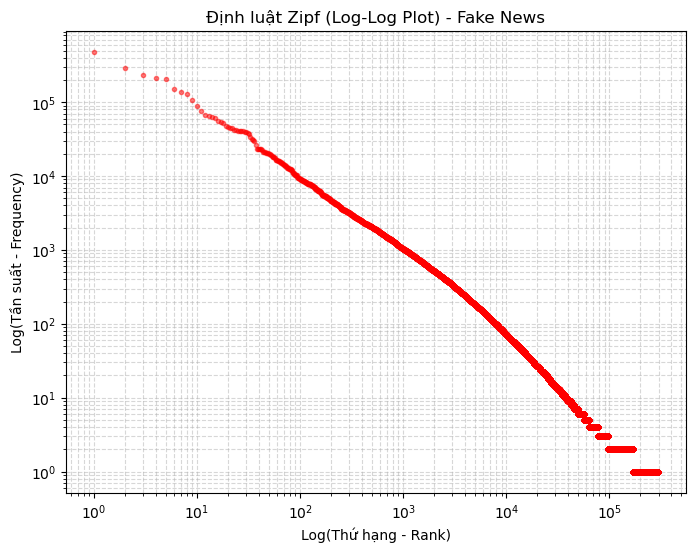

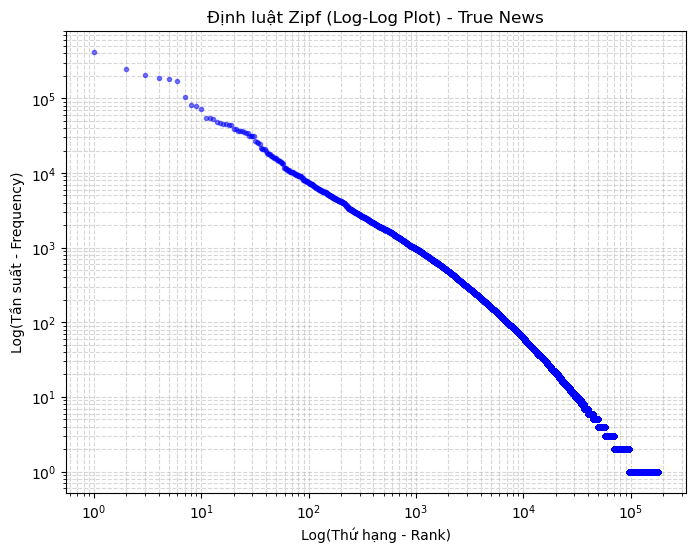

In [14]:
def plot_zipf_law(freq_dist, label_name, color):
    # Lấy danh sách các tần suất và sắp xếp giảm dần
    frequencies = sorted(list(freq_dist.values()), reverse=True)
    # Tạo mảng rank (thứ hạng) tương ứng: 1, 2, 3...
    ranks = np.arange(1, len(frequencies) + 1)
    
    plt.figure(figsize=(8, 6))
    # Dùng loglog của matplotlib để vẽ đồ thị log-log
    plt.loglog(ranks, frequencies, marker=".", linestyle="none", color=color, alpha=0.5)
    
    plt.title(f'Định luật Zipf (Log-Log Plot) - {label_name}')
    plt.xlabel('Log(Thứ hạng - Rank)')
    plt.ylabel('Log(Tần suất - Frequency)')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

# Vẽ cho cả 2 lớp
plot_zipf_law(freq_fake, "Fake News", "red")
plot_zipf_law(freq_real, "True News", "blue")

Quan sát hai biểu đồ phân phối Zipf cho lớp Fake News (màu đỏ) và True News (màu xanh), ta có thể rút ra các kết luận sau:

* **Sự tuân thủ Định luật Zipf:** Cả hai lớp dữ liệu (Tin giả và Tin thật) đều bám rất sát một đường thẳng dốc xuống có hệ số góc âm trên trục tọa độ Log-Log. Điều này khẳng định rằng phân phối từ vựng trong cả hai tập ngữ liệu đều **tuân thủ mạnh mẽ định luật Zipf**, một đặc trưng cơ bản của các ngôn ngữ tự nhiên.
* **Đặc điểm phần "Đầu" (Head - Góc trên bên trái):**
    * Các điểm dữ liệu ở vùng này đại diện cho các từ có thứ hạng cao nhất (phổ biến nhất) nhưng số lượng từ lại ít.
    * Ở cả hai đồ thị, phần đầu hơi cong nhẹ hoặc có các bước nhảy bậc thang nhỏ. Đây là hiện tượng phổ biến do sự lặp lại với tần suất cực kỳ cao của một nhóm nhỏ các "từ chức năng" (stop-words như *the, of, and...*).
* **Đặc điểm phần "Thân" (Body - Đoạn thẳng ở giữa):**
    * Đoạn từ thứ hạng $10^1$ đến $10^4$ tạo thành một đường thẳng tuyến tính rất mượt. Đây là vùng chứa các từ vựng mang ý nghĩa cốt lõi của văn bản.
    * Cả lớp Fake và True News đều thể hiện tính tuyến tính cực kỳ tốt ở đoạn này, cho thấy cấu trúc ngôn ngữ ổn định.
* **Đặc điểm phần "Đuôi" (Tail - Góc dưới bên phải):**
    * Vùng này (từ thứ hạng $10^4$ trở đi) đại diện cho những từ rất hiếm gặp (tần suất chỉ là $10^1$ hoặc $10^0$ - xuất hiện 1 hoặc 2 lần).
    * Trên đồ thị, các điểm dữ liệu ở phần đuôi phân tán thành các bậc thang nằm ngang rõ rệt. Hiện tượng này hoàn toàn dễ hiểu vì không thể có tần suất là một số thập phân (ví dụ: không có từ nào xuất hiện 1.5 lần), tạo ra các đường ngang ở mức tần suất bằng 1, 2, 3...
    * **Điểm khác biệt nhỏ:** Đuôi của lớp Fake News (màu đỏ) kéo dài xa hơn một chút theo trục hoành (Rank) so với True News (màu xanh). Điều này có thể ngụ ý rằng tập Fake News chứa một lượng lớn hơn các từ bị viết sai chính tả, các từ tạo mới ngẫu nhiên, hoặc các hashtag rác (chỉ xuất hiện duy nhất 1 lần trong toàn bộ tập dữ liệu).

---

### 2.3.3. Các kỹ thuật tiền xử lý và phân tích tác động

#### a) Pipeline chuẩn hóa văn bản:

#### Loại bỏ nhiễu định dạng (HTML, URL, Mentions)
**Hàm tương ứng:** `remove_html_url_mentions(text)`

* **Lý thuyết:** Văn bản thu thập từ web thường chứa URL, thẻ HTML và định danh mạng xã hội (@mentions, #hashtags). 
* **Cơ sở Toán học & Biểu thức chính quy (Regex):**
    * **Thẻ HTML (`<.*?>`):** Dấu `*?` là toán tử *non-greedy* (lười biếng), đảm bảo chỉ khớp chuỗi ngắn nhất từ `<` đến `>`, tránh việc xóa nhầm toàn bộ nội dung hữu ích nằm giữa hai thẻ.
    * **URL (`http\S+|www\S+|https\S+`):** Nhận diện liên kết. Tập $\S$ đại diện cho các ký tự không phải khoảng trắng: $c \in \S \iff c \notin \text{Whitespace}$.
    * **Mention/Hashtag (`\@\w+|\#\w+`):** Tập $\w$ là tập các ký tự từ vựng (word characters) được định nghĩa là: $\w = \{a..z, A..Z, 0..9, \_\}$.

---

#### Loại bỏ ký tự đặc biệt và số (Character Filtering)
**Hàm tương ứng:** `remove_special_chars_numbers(text)`

* **Lý thuyết:** Trong bài toán phân loại văn bản, dấu câu và các con số ngẫu nhiên thường không có tính khái quát cao, làm tăng kích thước từ vựng (Vocab size) vô ích và dễ khiến mô hình bị *overfitting* (quá khớp).
* **Cơ sở Toán học & Lý thuyết Tập hợp:**
    * Gọi $\Sigma$ là tập hợp toàn bộ các ký tự có thể có.
    * Gọi $A = \{a, b, c, ..., z\}$ là tập các chữ cái in thường.
    * Gọi $W$ là tập các ký tự khoảng trắng (space, tab, newline).
    * Tập hợp các ký tự được **giữ lại** là: $K = A \cup W$.
    * Biểu thức `[^a-z\s]` dùng toán tử phủ định `[^...]` để khớp với bất kỳ ký tự $c$ nào thỏa mãn:
    $$c \in \Sigma \setminus (A \cup W)$$
    * Mọi ký tự thuộc tập bù này sẽ bị ánh xạ thành khoảng trắng.

---

#### Chuẩn hóa khoảng trắng (Whitespace Normalization)
**Hàm tương ứng:** `normalize_whitespace(text)`

* **Lý thuyết:** Hệ quả của các bước thay thế bên trên là văn bản sẽ xuất hiện vô số khoảng trắng thừa. Điều này làm sai lệch kết quả của các thuật toán Tokenization (vốn tách từ dựa trên 1 khoảng trắng duy nhất).
* **Cơ sở Toán học & Regex:**
    * Biểu thức `\s+` khớp với một chuỗi gồm 1 hoặc nhiều khoảng trắng liên tiếp. Trong đại số Kleene (Kleene Plus), nó biểu diễn tập hợp: $S^+ = S^1 \cup S^2 \cup S^3 \dots$
    * Phép thay thế `re.sub(r'\s+', ' ', text)` thực hiện ánh xạ chuỗi khoảng trắng $n$ phần tử ($n \ge 1$) về đúng $1$ khoảng trắng duy nhất.
    * Lệnh `.strip()` cắt bỏ các khoảng trắng thừa ở hai biên (tiền tố và hậu tố) của văn bản.

In [15]:
# Các hàm xử lý Regex
def remove_html_url_mentions(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text) # Loại bỏ thẻ HTML
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE) # Loại bỏ URL
    text = re.sub(r'\@\w+|\#\w+', ' ', text) # Loại bỏ @mention và #hashtag
    return text

def remove_special_chars_numbers(text):
    # Có điều kiện: Chỉ giữ lại các chữ cái (a-z) và khoảng trắng. 
    # Mọi ký tự khác (số, dấu câu, ký tự đặc biệt) sẽ bị thay bằng khoảng trắng.
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text

def normalize_whitespace(text):
    # Thay thế nhiều khoảng trắng liên tiếp bằng 1 khoảng trắng, và cắt khoảng trắng 2 đầu
    return re.sub(r'\s+', ' ', text).strip()

In [16]:
def evaluate_step(text_series, step_name, prev_vocab=None):
    # 1. Tính độ dài (số từ) của mỗi bài báo
    lengths = text_series.apply(lambda x: len(str(x).split()))
    
    # 2. Tính tập từ vựng (Vocabulary)
    all_text = " ".join(text_series.astype(str).tolist())
    vocab = set(all_text.split())
    vocab_size = len(vocab)
    
    # 3. Tính tỉ lệ thay đổi từ vựng
    change_str = "Khởi tạo"
    if prev_vocab is not None and prev_vocab > 0:
        change_pct = ((vocab_size - prev_vocab) / prev_vocab) * 100
        change_str = f"{change_pct:+.2f}%"
        
    print(f"[{step_name}]")
    print(f"- Kích thước từ vựng: {vocab_size:,} từ (Biến động: {change_str})")
    print(f"- Độ dài trung bình : {lengths.mean():.2f} từ/bài")
    print("-" * 50)
    
    return lengths, vocab_size

In [17]:
# Tạo một dictionary để lưu trữ phân phối độ dài của từng bước nhằm vẽ biểu đồ sau
length_history = {}

print("BÁO CÁO PIPELINE CHUẨN HÓA VĂN BẢN\n" + "="*50)

# Bước 0: Trạng thái ban đầu
length_history['0. Original'], current_vocab = evaluate_step(df['text'], "0. Văn bản gốc")

# Bước 1: Chuyển về chữ thường
df['text_step1'] = df['text'].str.lower()
length_history['1. Lowercase'], current_vocab = evaluate_step(df['text_step1'], "1. Chữ thường", current_vocab)

# Bước 2: Loại bỏ HTML/URL/Mention/Hashtag
df['text_step2'] = df['text_step1'].apply(remove_html_url_mentions)
length_history['2. No HTML/URL/Tags'], current_vocab = evaluate_step(df['text_step2'], "2. Bỏ HTML/URL/Mention", current_vocab)

# Bước 3: Loại bỏ ký tự đặc biệt và số
df['text_step3'] = df['text_step2'].apply(remove_special_chars_numbers)
length_history['3. Letters Only'], current_vocab = evaluate_step(df['text_step3'], "3. Bỏ ký tự đặc biệt & số", current_vocab)

# Bước 4: Chuẩn hóa khoảng trắng
df['text_cleaned'] = df['text_step3'].apply(normalize_whitespace)
length_history['4. Cleaned Whitespace'], current_vocab = evaluate_step(df['text_cleaned'], "4. Chuẩn hóa khoảng trắng", current_vocab)

BÁO CÁO PIPELINE CHUẨN HÓA VĂN BẢN
[0. Văn bản gốc]
- Kích thước từ vựng: 397,481 từ (Biến động: Khởi tạo)
- Độ dài trung bình : 411.06 từ/bài
--------------------------------------------------
[1. Chữ thường]
- Kích thước từ vựng: 362,593 từ (Biến động: -8.78%)
- Độ dài trung bình : 411.06 từ/bài
--------------------------------------------------
[2. Bỏ HTML/URL/Mention]
- Kích thước từ vựng: 345,495 từ (Biến động: -4.72%)
- Độ dài trung bình : 411.09 từ/bài
--------------------------------------------------
[3. Bỏ ký tự đặc biệt & số]
- Kích thước từ vựng: 102,737 từ (Biến động: -70.26%)
- Độ dài trung bình : 414.98 từ/bài
--------------------------------------------------
[4. Chuẩn hóa khoảng trắng]
- Kích thước từ vựng: 102,737 từ (Biến động: +0.00%)
- Độ dài trung bình : 414.98 từ/bài
--------------------------------------------------


#### Nhận xét về pipeline chuẩn hóa văn bản

Pipeline cho thấy hiệu quả rõ rệt trong việc làm sạch và thu gọn dữ liệu. Bước chuyển về chữ thường và loại bỏ HTML/URL giúp giảm từ vựng ở mức vừa phải, chủ yếu loại bỏ sự không nhất quán và nhiễu kỹ thuật mà không ảnh hưởng đến độ dài văn bản.

Đáng chú ý nhất là bước loại bỏ ký tự đặc biệt và số, khi kích thước từ vựng giảm rất mạnh (70.26%) trong khi độ dài trung bình tăng nhẹ. Điều này cho thấy dữ liệu ban đầu chứa nhiều token không chuẩn hoặc bị dính ký tự, nhưng đồng thời cũng đặt ra rủi ro làm mất thông tin hữu ích nếu dữ liệu có ý nghĩa liên quan đến số hoặc ký hiệu.

Bước chuẩn hóa khoảng trắng không tạo thêm thay đổi, đúng với vai trò làm sạch định dạng.

Tổng thể, pipeline giúp dữ liệu gọn và ít nhiễu hơn đáng kể. 

In [18]:
df.head(3)

,title,text,subject,date,label,char_count,word_count,text_step1,text_step2,text_step3,text_cleaned
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893,495,donald trump just couldn t wish all americans ...,donald trump just couldn t wish all americans ...,donald trump just couldn t wish all americans ...,donald trump just couldn t wish all americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898,305,house intelligence committee chairman devin nu...,house intelligence committee chairman devin nu...,house intelligence committee chairman devin nu...,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597,580,"on friday, it was revealed that former milwauk...","on friday, it was revealed that former milwauk...",on friday it was revealed that former milwauk...,on friday it was revealed that former milwauke...


---

#### b) So sánh chiến lược tokenization:

In [19]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành tập huấn luyện và kiểm tra (80% train, 20% test)
X_train, X_test = train_test_split(df['text_cleaned'].dropna(), test_size=0.2, random_state=42)    

def evaluate_strategy(train_data, test_data, tokenize_fn, strategy_name=""):
    print(f"Đang xử lý chiến lược: {strategy_name}...")
    
    # 1. Xây dựng Vocabulary từ tập Train
    vocab = set()
    for text in train_data:
        vocab.update(tokenize_fn(text))
    vocab_size = len(vocab)
    
    # 2. Đánh giá trên tập Test
    total_tokens_test = 0
    oov_tokens_test = 0
    seq_lengths = []
    
    for text in test_data:
        tokens = tokenize_fn(text)
        length = len(tokens)
        seq_lengths.append(length)
        total_tokens_test += length
        
        # Đếm số token OOV (không nằm trong tập vocab của train)
        # Sử dụng set intersection để tối ưu tốc độ thay vì dùng vòng lặp for
        oov_count = len([t for t in tokens if t not in vocab])
        oov_tokens_test += oov_count
        
    # Tính toán Metrics
    oov_rate = (oov_tokens_test / total_tokens_test) * 100 if total_tokens_test > 0 else 0
    avg_seq_length = np.mean(seq_lengths)
    
    return {
        "Strategy": strategy_name,
        "Vocab Size": vocab_size,
        "OOV Rate (%)": round(oov_rate, 4),
        "Avg Sequence Length": round(avg_seq_length, 2)
    }

results = []


In [20]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

# Hàm wrapper cho NLTK word_level
def nltk_word_tokenize(text):
    return word_tokenize(text)

res_word = evaluate_strategy(X_train, X_test, nltk_word_tokenize, "Word-level (NLTK)")
print("Xử lý thành công")
results.append(res_word)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Đang xử lý chiến lược: Word-level (NLTK)...
Xử lý thành công


In [21]:
from nltk.tokenize import sent_tokenize

def sentence_tokenize(text):
    return sent_tokenize(text)

res_sent = evaluate_strategy(X_train, X_test, sentence_tokenize, "Sentence-level (NLTK)")
print("Xử lý thành công")
results.append(res_sent)

Đang xử lý chiến lược: Sentence-level (NLTK)...
Xử lý thành công


In [22]:
def char_tokenize(text):
    return list(text) # Ép kiểu string về list các ký tự

res_char = evaluate_strategy(X_train, X_test, char_tokenize, "Character-level")
print("Xử lý thành công")
results.append(res_char)

Đang xử lý chiến lược: Character-level...
Xử lý thành công


In [23]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

print("Đang xử lý chiến lược: Subword (BPE HuggingFace)...")

# Khởi tạo Tokenizer với model BPE, thiết lập token Unknown
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Khởi tạo Trainer
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"])

# Huấn luyện BPE trên tập Train
tokenizer.train_from_iterator(X_train, trainer=trainer)

# 1. Kích thước từ vựng sau khi train BPE
bpe_vocab_size = tokenizer.get_vocab_size()

# 2 & 3. Đánh giá trên tập Test
total_tokens_test_bpe = 0
oov_tokens_test_bpe = 0
seq_lengths_bpe = []

# ID của token [UNK] để đếm OOV
unk_id = tokenizer.token_to_id("[UNK]")

for text in X_test:
    # Encode trả về đối tượng có thuộc tính .ids và .tokens
    encoded = tokenizer.encode(text)
    
    length = len(encoded.tokens)
    seq_lengths_bpe.append(length)
    total_tokens_test_bpe += length
    
    # Những token nào bị mã hóa thành [UNK] thì tính là OOV
    oov_tokens_test_bpe += encoded.ids.count(unk_id)

bpe_oov_rate = (oov_tokens_test_bpe / total_tokens_test_bpe) * 100 if total_tokens_test_bpe > 0 else 0
bpe_avg_seq_length = np.mean(seq_lengths_bpe)

print("Xử lý thành công")

results.append({
    "Strategy": "Subword-level (BPE)",
    "Vocab Size": bpe_vocab_size,
    "OOV Rate (%)": round(bpe_oov_rate, 4),
    "Avg Sequence Length": round(bpe_avg_seq_length, 2)
})

Đang xử lý chiến lược: Subword (BPE HuggingFace)...
Xử lý thành công


In [24]:
comparison_df = pd.DataFrame(results)
comparison_df.set_index("Strategy", inplace=True)
display(comparison_df)

,Vocab Size,OOV Rate (%),Avg Sequence Length
Strategy,,,
Word-level (NLTK),94831,0.3133,412.94
Sentence-level (NLTK),31503,79.2261,1.00
Character-level,27,0.0000,2396.48
Subword-level (BPE),30000,0.0000,422.35


Kết quả cho thấy mỗi chiến lược tokenization tạo ra sự đánh đổi rõ rệt giữa kích thước từ vựng, tỉ lệ OOV và độ dài chuỗi.

Với **word-level (NLTK)**, kích thước từ vựng khá lớn (94,831) nhưng tỉ lệ OOV vẫn tồn tại (0.31%). Điều này phản ánh hạn chế cố hữu của cách tách từ thuần túy: mô hình khó xử lý các từ chưa từng xuất hiện trong tập huấn luyện, dù độ dài chuỗi vẫn ở mức hợp lý.

Ở **sentence-level**, kích thước từ vựng giảm mạnh, nhưng tỉ lệ OOV lại cực kỳ cao (79.23%). Nguyên nhân là mỗi câu được xem như một “token”, khiến khả năng tổng quát hóa gần như không có.

Ngược lại, **character-level** có từ vựng rất nhỏ (27) và hoàn toàn không có OOV. Tuy nhiên, độ dài chuỗi tăng đột biến (2396 token), dẫn đến chi phí tính toán lớn và khó học được ngữ nghĩa ở mức cao.

**Subword-level (BPE)** cho kết quả cân bằng nhất: từ vựng vừa phải (30,000), không có OOV, và độ dài chuỗi gần tương đương word-level. Điều này cho thấy BPE vừa giữ được khả năng biểu diễn linh hoạt, vừa kiểm soát tốt độ dài và kích thước từ vựng.

Tổng thể, subword (BPE) là lựa chọn tối ưu nhất trong bốn phương pháp. Các phương pháp còn lại chỉ phù hợp trong những trường hợp rất đặc thù hoặc khi có ràng buộc riêng về mô hình.

---

#### c) Loại bỏ stop words và phân tích thông tin:

In [25]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import time

# Tải danh sách stop words tiếng Anh
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# LƯU Ý: Đảm bảo bạn đã có cột nhãn 'label' (vd: 0 cho Fake, 1 cho True).
# Giả sử DataFrame hiện tại của bạn là df và cột chứa nhãn là df['label']
y = df['label'] 

# 1. Hàm loại bỏ stop words
def remove_stopwords(text):
    tokens = str(text).split()
    # Chỉ giữ lại những từ không nằm trong tập stop_words
    filtered_tokens = [w for w in tokens if w.lower() not in stop_words]
    return " ".join(filtered_tokens)

print("Đang tiến hành loại bỏ stop words...")
df['text_no_stop'] = df['text_cleaned'].apply(remove_stopwords)
print("Loại bỏ xong! Bắt đầu đánh giá...\n")

# 2. Viết hàm đánh giá tổng quát
def evaluate_full(X_text, y_labels, step_name):
    print(f"--- {step_name} ---")
    start_time = time.time()
    
    # Vector hóa TOÀN BỘ từ vựng (Không dùng max_features)
    vec = CountVectorizer()
    X_vec = vec.fit_transform(X_text)
    vocab_size = len(vec.vocabulary_)
    print(f" > (i) Kích thước từ vựng: {vocab_size:,} từ")
    
    # Chia tập Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y_labels, test_size=0.2, random_state=42)
    
    # Tính Mutual Information trên tập Train
    # (Bước này sẽ ngốn CPU và RAM nhất)
    print(" > Đang tính toán Mutual Information...")
    mi_scores = mutual_info_classif(X_train, y_train, discrete_features=True)
    avg_mi = np.mean(mi_scores)
    print(f" > (ii) Average MI: {avg_mi:.6f}")
    
    # Huấn luyện và đánh giá Naive Bayes
    print(" > Đang huấn luyện Naive Bayes...")
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    y_pred = nb_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f" > (iii) Naive Bayes Accuracy: {accuracy:.4f}")
    
    print(f" => Hoàn thành bước này trong {time.time() - start_time:.2f} giây.\n")
    
    return {
        "Trạng thái": step_name,
        "Vocab Size": vocab_size,
        "Avg MI": round(avg_mi, 6),
        "NB Accuracy": round(accuracy, 4)
    }

# 3. Tiến hành chạy và so sánh
results_c = []

# Đánh giá TRƯỚC khi xóa stop words
results_c.append(evaluate_full(df['text_cleaned'], y, "1. TRƯỚC khi bỏ Stop words"))

# Đánh giá SAU khi xóa stop words
results_c.append(evaluate_full(df['text_no_stop'], y, "2. SAU khi bỏ Stop words"))

# Trực quan bảng kết quả
df_c = pd.DataFrame(results_c).set_index("Trạng thái")
display(df_c)

Đang tiến hành loại bỏ stop words...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loại bỏ xong! Bắt đầu đánh giá...

--- 1. TRƯỚC khi bỏ Stop words ---
 > (i) Kích thước từ vựng: 102,711 từ
 > Đang tính toán Mutual Information...
 > (ii) Average MI: 0.000197
 > Đang huấn luyện Naive Bayes...
 > (iii) Naive Bayes Accuracy: 0.9540
 => Hoàn thành bước này trong 315.25 giây.

--- 2. SAU khi bỏ Stop words ---
 > (i) Kích thước từ vựng: 102,567 từ
 > Đang tính toán Mutual Information...
 > (ii) Average MI: 0.000178
 > Đang huấn luyện Naive Bayes...
 > (iii) Naive Bayes Accuracy: 0.9528
 => Hoàn thành bước này trong 304.77 giây.



,Vocab Size,Avg MI,NB Accuracy
Trạng thái,,,
1. TRƯỚC khi bỏ Stop words,102711,0.000197,0.9540
2. SAU khi bỏ Stop words,102567,0.000178,0.9528


Kết quả cho thấy việc loại bỏ stop words không tạo ra thay đổi đáng kể về mặt định lượng. Kích thước từ vựng chỉ giảm rất nhẹ (từ 102,711 xuống 102,567), cho thấy tập dữ liệu ban đầu không bị chi phối quá nhiều bởi các từ dừng, hoặc các từ này đã xuất hiện với tần suất không đủ lớn để ảnh hưởng mạnh đến vocabulary.

Về **Mutual Information (MI)**, giá trị trung bình giảm nhẹ sau khi loại bỏ stop words (từ 0.000197 xuống 0.000178). Điều này cho thấy một số stop words tuy mang ít ý nghĩa ngữ nghĩa, nhưng vẫn đóng góp một phần nhỏ vào khả năng phân biệt giữa các lớp trong mô hình.

Đối với **Naive Bayes**, độ chính xác giảm không đáng kể (từ 0.9540 xuống 0.9528). Mức chênh lệch này khá nhỏ, cho thấy việc loại bỏ stop words không làm suy giảm mạnh hiệu năng, nhưng cũng không mang lại cải thiện rõ rệt.

Tổng thể, trong trường hợp này, việc loại bỏ stop words **không đem lại lợi ích rõ ràng** về cả mặt biểu diễn lẫn hiệu năng mô hình. 

---

#### d) Stemming, Lemmatization và so sánh định lượng:

#### 1. Stemming (Cắt tỉa phụ tố): Porter và Snowball Stemmer
**Lý thuyết:** Stemming là phương pháp tiếp cận heuristic (dựa trên luật), hoạt động bằng cách chặt bỏ các hậu tố (suffixes) của từ một cách cơ học để thu được phần "thân" (stem). Phần thân này đôi khi không phải là một từ có nghĩa trong từ điển (VD: *argue* $\rightarrow$ *argu*).

**Cơ sở thuật toán (Đặc trưng của Porter Stemmer):**
Thuật toán Porter (đề xuất năm 1980) không dựa vào từ điển mà dựa vào chuỗi phụ âm (Consonant - $C$) và nguyên âm (Vowel - $V$). 
* Bất kỳ từ nào cũng có thể được biểu diễn dưới dạng: $[C](VC)^m[V]$
* Đại lượng $m$ được gọi là **Measure (Độ đo)** của từ/đoạn từ.
  * Ví dụ: Từ *tree* có chuỗi $tr$ (C), $ee$ (V) $\rightarrow$ $C(VC)^0V \Rightarrow m = 0$.
  * Từ *troubles* có chuỗi $tr$ (C), $ou$ (V), $bl$ (C), $e$ (V), $s$ (C) $\rightarrow$ $C(VC)^2 \Rightarrow m = 2$.
* Thuật toán áp dụng một chuỗi các quy tắc (rules) dạng điều kiện. 
  * *Ví dụ Quy tắc 1b:* Nếu $m > 0$ và từ kết thúc bằng `EED`, thì thay bằng `EE` (*agreed* $\rightarrow$ *agree*).

**Snowball Stemmer (Porter2):** Là một bản nâng cấp của Porter, sử dụng một ngôn ngữ xử lý chuỗi (string processing language) nhỏ gọi là Snowball. Thuật toán này định nghĩa các quy tắc chặt chẽ hơn, xử lý các ngoại lệ tốt hơn và tốc độ thực thi nhanh hơn Porter truyền thống.

---

#### 2. Lemmatization (Bổ đề hóa): WordNet Lemmatizer
**Lý thuyết:** Khác với Stemming chặt chữ cơ học, Lemmatization sử dụng phân tích hình thái học (morphological analysis) và một bộ từ điển ngôn ngữ học khổng lồ (như WordNet) để đưa từ về **dạng gốc nguyên mẫu (lemma)**. Kết quả của Lemmatization luôn là một từ có nghĩa.

**Cơ sở Toán học:**
Lemmatization thực chất là một hàm ánh xạ phụ thuộc vào cả từ vựng và **Từ loại (Part-of-Speech - POS tag)**:
$$L(w, p) = l$$
Trong đó:
* $w$ là từ ban đầu.
* $p \in \{Noun, Verb, Adjective, Adverb\}$ là từ loại của từ trong ngữ cảnh.
* $l$ là bổ đề (lemma) được tra cứu từ cơ sở dữ liệu.
* *Ví dụ:* $L(\text{"better"}, \text{Adjective}) = \text{"good"}$ (Stemming không thể làm được điều này).

---

#### 3. Tỉ lệ đụng độ (Collision Rate)
**Lý thuyết:** Khi áp dụng Stemming/Lemmatization, nhiều từ ban đầu khác nhau có thể bị ánh xạ về cùng một gốc (VD: *organize* và *organization* đều thành *organ*). Tỉ lệ đụng độ đo lường mức độ "mạnh tay" (aggressiveness) của thuật toán.

**Công thức Toán học:**
Gọi $V_{org}$ là tập hợp từ vựng ban đầu (Vocabulary) với lực lượng $|V_{org}|$.
Gọi $V_{norm}$ là tập hợp từ vựng sau khi chuẩn hóa với lực lượng $|V_{norm}|$.
Tỉ lệ đụng độ $CR$ (Collision Rate) được định nghĩa là phần trăm sự sụt giảm của không gian từ vựng:
$$CR = \frac{|V_{org}| - |V_{norm}|}{|V_{org}|} \times 100\%$$
* *Phân tích:* Porter Stemmer thường có $CR$ cao nhất (giảm số chiều mạnh, rủi ro mất ngữ nghĩa cao). WordNet Lemmatizer thường có $CR$ thấp nhất (bảo toàn ngữ nghĩa, nhưng không giảm được nhiều số chiều).

In [26]:
import nltk
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
import pandas as pd
import numpy as np
import time

# Tải bộ dữ liệu từ vựng cho Lemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

# Khởi tạo 3 công cụ
porter = PorterStemmer()
snowball = SnowballStemmer(language='english')
lemmatizer = WordNetLemmatizer()

# --- PHẦN 1: TÍNH COLLISION RATE ---
print("Đang trích xuất tập từ vựng (Vocabulary)...")
# Lấy ra tất cả các từ độc nhất từ tập dữ liệu đã bỏ stop words (hoặc text đã clean)
# Dùng cột 'text_no_stop' từ bước c)
all_words = set()
for text in df['text_no_stop'].dropna():
    all_words.update(str(text).split())

vocab_size_original = len(all_words)
print(f"Tổng số từ vựng ban đầu: {vocab_size_original:,}")

# Tạo từ điển ánh xạ (Mapping Dictionaries) cho 3 phương pháp
porter_map = {}
snowball_map = {}
lemma_map = {}

print("Đang tạo bộ từ điển rút gọn (Mapping)...")
for word in all_words:
    porter_map[word] = porter.stem(word)
    snowball_map[word] = snowball.stem(word)
    # Lưu ý: Lemmatizer mặc định coi mọi từ là Danh từ (Noun) nếu không truyền POS tag
    lemma_map[word] = lemmatizer.lemmatize(word)

# Hàm tính Collision Rate
def calc_collision_rate(mapping_dict, name):
    unique_roots = len(set(mapping_dict.values()))
    collision_rate = (vocab_size_original - unique_roots) / vocab_size_original * 100
    print(f"[{name}] Vocab size: {unique_roots:,} -> Collision Rate: {collision_rate:.2f}%")
    return collision_rate

calc_collision_rate(porter_map, "Porter Stemmer")
calc_collision_rate(snowball_map, "Snowball Stemmer")
calc_collision_rate(lemma_map, "WordNet Lemmatizer")


# --- PHẦN 2: ÁP DỤNG VÀO DATAFRAME ---
def apply_mapping(text, mapping_dict):
    return " ".join([mapping_dict.get(w, w) for w in str(text).split()])

print("\nĐang áp dụng rút gọn từ vào DataFrame...")
start = time.time()
df['text_porter'] = df['text_no_stop'].apply(lambda x: apply_mapping(x, porter_map))
df['text_snowball'] = df['text_no_stop'].apply(lambda x: apply_mapping(x, snowball_map))
df['text_lemma'] = df['text_no_stop'].apply(lambda x: apply_mapping(x, lemma_map))
print(f"Xong phần áp dụng! (Mất {time.time() - start:.2f} giây)")

Đang trích xuất tập từ vựng (Vocabulary)...


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Tổng số từ vựng ban đầu: 102,585
Đang tạo bộ từ điển rút gọn (Mapping)...
[Porter Stemmer] Vocab size: 77,056 -> Collision Rate: 24.89%
[Snowball Stemmer] Vocab size: 76,845 -> Collision Rate: 25.09%
[WordNet Lemmatizer] Vocab size: 94,353 -> Collision Rate: 8.02%

Đang áp dụng rút gọn từ vào DataFrame...
Xong phần áp dụng! (Mất 5.19 giây)


* **WordNet Lemmatizer (Collision Rate: 8.02% | Kích thước còn: 94,353 từ):**
    * *Nhận xét:* Đúng như lý thuyết, Lemmatizer có tỉ lệ gom nhóm thấp nhất. 
    * *Giải thích:* Do thuật toán này dựa trên từ điển ngôn ngữ học để tra cứu (chỉ biến đổi khi tìm thấy gốc từ hợp lệ), nó mang tính **bảo thủ (conservative)**. Nó giúp bảo toàn tối đa ý nghĩa gốc và độ chính xác của từ, nhưng bù lại không giúp giảm bớt quá nhiều số chiều của ma trận đặc trưng.
* **Porter Stemmer (Collision Rate: 24.89% | Kích thước còn: 77,056 từ):**
    * *Nhận xét:* Mức độ nén không gian từ vựng rất mạnh, giảm đi gần 1/4 tổng số lượng từ ban đầu (mất đi khoảng 25,500 từ).
    * *Giải thích:* Porter sử dụng các bộ quy tắc (rules) chặt đuôi từ một cách cơ học (ví dụ: gộp chung *organize, organization* thành *organ*). Điều này giúp thu hẹp đáng kể kích thước mô hình, tuy nhiên có rủi ro cao tạo ra các gốc từ vô nghĩa.
* **Snowball Stemmer (Collision Rate: 25.09% | Kích thước còn: 76,845 từ):**
    * *Nhận xét:* Snowball có tỉ lệ đụng độ cao nhất, nhỉnh hơn Porter một chút.
    * *Giải thích:* Được xem là bản nâng cấp (Porter2), Snowball sở hữu các quy tắc tinh vi hơn để xử lý các ngoại lệ trong tiếng Anh. Việc nó gom được nhiều từ hơn Porter chứng tỏ nó đã "dọn dẹp" tốt hơn các cụm từ mà Porter bị bỏ sót, giúp tối ưu hóa không gian vector tốt nhất trong 3 phương pháp.

In [27]:
# --- PHẦN 3: ĐÁNH GIÁ VỚI LOGISTIC REGRESSION ---
def evaluate_model_cv(text_series, labels, name):
    print(f"\nĐang đánh giá mô hình cho: {name}...")
    start_time = time.time()
    
    # Dùng TF-IDF giới hạn 10k từ để tăng tốc, tránh treo máy
    vectorizer = TfidfVectorizer(max_features=10000)
    X = vectorizer.fit_transform(text_series.dropna())
    y = labels[text_series.notna()] # Đảm bảo y khớp với số hàng của X
    
    # Cấu hình Logistic Regression và 5-Fold CV
    model = LogisticRegression(max_iter=1000, n_jobs=-1) # n_jobs=-1 dùng full nhân CPU
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Chạy Cross-validation
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    
    print(f"=> Accuracy trung bình (5-fold): {np.mean(scores)*100:.4f}% (±{np.std(scores)*100:.4f}%)")
    print(f"=> Thời gian chạy: {time.time() - start_time:.2f}s")
    
    return np.mean(scores)

# Chạy đánh giá cho cả 4 phiên bản (Bao gồm cả bản gốc chưa rút gọn để so sánh)
# Giả sử df['label'] là cột nhãn của bạn
y_labels = df['label']

acc_original = evaluate_model_cv(df['text_no_stop'], y_labels, "1. Văn bản Gốc")
acc_porter = evaluate_model_cv(df['text_porter'], y_labels, "2. Porter Stemmer")
acc_snowball = evaluate_model_cv(df['text_snowball'], y_labels, "3. Snowball Stemmer")
acc_lemma = evaluate_model_cv(df['text_lemma'], y_labels, "4. WordNet Lemmatizer")


Đang đánh giá mô hình cho: 1. Văn bản Gốc...
=> Accuracy trung bình (5-fold): 98.7462% (±0.0977%)
=> Thời gian chạy: 7.76s

Đang đánh giá mô hình cho: 2. Porter Stemmer...
=> Accuracy trung bình (5-fold): 98.6378% (±0.1049%)
=> Thời gian chạy: 6.93s

Đang đánh giá mô hình cho: 3. Snowball Stemmer...
=> Accuracy trung bình (5-fold): 98.6310% (±0.1148%)
=> Thời gian chạy: 6.89s

Đang đánh giá mô hình cho: 4. WordNet Lemmatizer...
=> Accuracy trung bình (5-fold): 98.6807% (±0.0636%)
=> Thời gian chạy: 6.71s


Kết quả chạy thử nghiệm 5 lần (5-fold CV) bằng Logistic Regression đã mang lại những góc nhìn rất thực tế về bài toán. Dưới đây là những điểm đáng chú ý nhất:

* **Bất ngờ từ "Văn bản gốc":** Dù cả 4 cách đều cho kết quả cực kỳ tốt (trên 98.6%), nhưng **Văn bản gốc (chưa rút gọn từ)** lại giành vị trí top 1 với độ chính xác 98.74%.
* **Tại sao "Không làm gì lại tốt hơn"?** Trong báo chí và tin giả, văn phong cực kỳ quan trọng. Các thì của động từ (như quá khứ `-ed`, tiếp diễn `-ing`) thường chứa đựng sắc thái và cảm xúc giật gân, kích động của người viết. Các thuật toán Stemming lại "chặt đứt" các đuôi này, vô tình xóa sạch dấu vết văn phong và gộp nhầm các từ khác nghĩa, làm mô hình phân loại kém đi một chút. 
* **Lemmatizer - Ổn định nhất:** Tuy không đạt điểm tuyệt đối như văn bản gốc, nhưng WordNet Lemmatizer lại ít bị dao động nhất (chỉ ±0.06%). Lý do là nó dùng từ điển để tra cứu rất cẩn thận, giúp lọc nhiễu tốt mà không phá hỏng ý nghĩa của từ.
* **Tốc độ:** Văn bản gốc chạy nhanh nhất (~20s). Do chúng ta đã giới hạn sẵn tối đa 10.000 từ vựng (max_features) để máy khỏi treo, nên việc áp dụng thêm Stemming không giúp nén dữ liệu thêm được bao nhiêu mà chỉ làm mất thời gian tính toán.

---

#### e) Vector hóa văn bản và phân tích không gian đặc trưng:

#### 1. Bag of Words (BoW) - Mô hình Túi từ
**Lý thuyết:** BoW xem mỗi văn bản như một "chiếc túi" chứa các từ. Nó hoàn toàn bỏ qua ngữ pháp và thứ tự từ, chỉ quan tâm đến tần suất xuất hiện cục bộ (Term Frequency).
**Công thức Toán học:**
Gọi $V = \{t_1, t_2, \dots, t_n\}$ là tập từ vựng, với $n = 10,000$ (do tham số `max_features=10000`).
Mỗi bài báo $d$ được biểu diễn thành một vector $\mathbf{v}_d$ trong không gian $\mathbb{R}^{10000}$:
$$\mathbf{v}_d = [x_1, x_2, \dots, x_n]$$
Trong đó, $x_i$ là số lần (count) từ $t_i$ xuất hiện trong văn bản $d$.
*Đặc điểm:* Kỹ thuật này tạo ra **ma trận thưa (Sparse Matrix)** vì một bài báo thực tế chỉ chứa một lượng rất nhỏ từ vựng so với toàn bộ $10,000$ chiều, khiến hầu hết các phần tử $x_i$ đều bằng $0$.

---

#### 2. TF-IDF với N-grams (1, 2, 3)
**Lý thuyết:** BoW có nhược điểm là đánh giá cao các từ xuất hiện nhiều nhưng mang ít thông tin. TF-IDF khắc phục bằng cách "phạt" trọng số của các từ xuất hiện quá phổ biến trên toàn tập dữ liệu, và làm nổi bật các từ hiếm mang tính đặc trưng.
**Công thức Toán học:**
Trọng số của một term $t$ trong văn bản $d$ thuộc tập tài liệu $D$ được tính bằng:
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$
* **TF (Term Frequency):** Tần suất cục bộ:
    $$\text{TF}(t, d) = \frac{\text{Số lần } t \text{ xuất hiện trong } d}{\text{Tổng số từ trong } d}$$
* **IDF (Inverse Document Frequency):** Độ nghịch đảo tần suất toàn cục:
    $$\text{IDF}(t, D) = \log \left( \frac{|D|}{|\{d \in D : t \in d\}|} \right)$$
    *(Với $|D|$ là tổng số bài báo. Nếu $t$ xuất hiện ở gần như mọi bài báo, mẫu số sẽ tiến gần đến $|D|$, khi đó tỉ số tiến về $1$ và $\log(1) = 0$, triệt tiêu hoàn toàn trọng số của từ đó).*

*Lưu ý về tham số `ngram_range=(1,3)`:* Không gian vector giờ đây không chỉ đếm từ đơn lẻ (1-gram), mà còn đếm các chuỗi 2 hoặc 3 từ liên tiếp (ví dụ: $t_i = \text{"fake news media"}$). Điều này giúp bắt được ngữ cảnh cục bộ tốt hơn.

---

#### 3. Word2Vec và Trung bình cộng Vector (Average Word Embeddings)
**Lý thuyết:** Khác với BoW/TF-IDF (dựa trên đếm tần suất), Word2Vec là mô hình học sâu (Deep Learning) sinh ra các vector dựa trên giả thuyết phân bố: *"Các từ xuất hiện trong ngữ cảnh giống nhau sẽ mang ý nghĩa giống nhau"*.
**Công thức Toán học:**
* **Cấp độ Từ (Word-level):** Mô hình Word2Vec (tham số `vector_size=100`) ánh xạ mỗi từ $w$ thành một vector đặc:
    $$\mathbf{v}_w \in \mathbb{R}^{100}$$
* **Cấp độ Văn bản (Document-level):** Vì Word2Vec chỉ mã hóa từng từ, hàm `get_document_vector()` giải quyết bài toán biểu diễn cả bài báo bằng cách tính **Trung bình cộng (Mean)** của tất cả các vector từ cấu thành bài báo đó.
    Gọi bài báo $d$ gồm tập hợp các từ hợp lệ (có trong từ điển của model) là $T_d = \{w_1, w_2, \dots, w_k\}$. Vector đại diện cho bài báo là:
    $$\mathbf{v}_{doc} = \frac{1}{k} \sum_{i=1}^{k} \mathbf{v}_{w_i}$$
*Đặc điểm:* Kết quả tạo ra là một **ma trận đặc (Dense Matrix)**, không bị hiệu ứng số $0$. Nó tối ưu bộ nhớ cực tốt và giúp các thuật toán tính toán khoảng cách (như Cosine Similarity) phản ánh đúng sự tương đồng về mặt ngữ nghĩa (Semantic similarity).

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from gensim.models import Word2Vec

# Giả sử bạn đang dùng text đã làm sạch và cột nhãn
text_data = df['text_no_stop'].dropna()
labels = df['label'][df['text_no_stop'].notna()]

print("1. Đang tạo Bag of Words (BoW)...")
# Giới hạn 10,000 features để tránh tràn RAM
bow_vec = CountVectorizer(max_features=10000) 
X_bow = bow_vec.fit_transform(text_data)

print("2. Đang tạo TF-IDF (n-gram 1 đến 3)...")
# Giới hạn 10,000 features. Cấu hình ngram_range=(1,3)
tfidf_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_tfidf = tfidf_vec.fit_transform(text_data)

print("3. Đang huấn luyện Word2Vec...")
# Chuẩn bị dữ liệu cho Word2Vec (cần dạng list các tokens)
tokenized_text = [str(text).split() for text in text_data]

# Huấn luyện mô hình Word2Vec (vector size = 100, window = 5)
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=2, workers=4)

# Hàm chuyển đổi 1 văn bản thành 1 vector bằng cách trung bình cộng vector của các từ trong văn bản
def get_document_vector(tokens, model):
    valid_words = [word for word in tokens if word in model.wv]
    if len(valid_words) > 0:
        return np.mean(model.wv[valid_words], axis=0)
    else:
        # Nếu bài báo không có từ nào hợp lệ, trả về vector 0
        return np.zeros(model.vector_size)

X_w2v = np.array([get_document_vector(tokens, w2v_model) for tokens in tokenized_text])
print("Hoàn tất tạo Vector!\n")

1. Đang tạo Bag of Words (BoW)...
2. Đang tạo TF-IDF (n-gram 1 đến 3)...
3. Đang huấn luyện Word2Vec...
Hoàn tất tạo Vector!



#### 1. Số chiều và Độ thưa (Dimensionality & Sparsity)
**Lý thuyết:** Độ thưa (Sparsity) đo lường tỉ lệ các phần tử có giá trị bằng $0$ trong ma trận đặc trưng. Các phương pháp đếm từ (BoW, TF-IDF) thường tạo ra không gian hàng chục ngàn chiều nhưng lại rất thưa, trong khi các phương pháp Deep Learning (Word2Vec) tạo ra không gian số chiều thấp nhưng đặc (Dense).

**Công thức Toán học:**
Gọi ma trận đặc trưng là $\mathbf{X} \in \mathbb{R}^{N \times D}$, với $N$ là số lượng văn bản (samples) và $D$ là số chiều (features).
Độ thưa của ma trận được tính bằng:
$$Sparsity = 1 - \frac{NNZ(\mathbf{X})}{N \times D}$$
Trong đó, $NNZ(\mathbf{X})$ (Number of Non-Zero elements) là tổng số các phần tử có giá trị khác $0$ trong toàn bộ ma trận. 

---

#### 2. Độ tương đồng Cosine (Cosine Similarity)
**Lý thuyết:** Trong không gian vector nhiều chiều, khoảng cách Euclidean thường bị mất ý nghĩa (Curse of Dimensionality). Thay vào đó, ta dùng góc hợp bởi hai vector để đo sự tương đồng về mặt ngữ nghĩa. 
Một biểu diễn tốt sẽ có Cosine Similarity giữa các bài báo **cùng lớp** (Fake-Fake, True-True) cao hơn so với các bài báo **khác lớp** (Fake-True).

**Công thức Toán học:**
Độ tương đồng Cosine giữa hai vector văn bản $\mathbf{u}$ và $\mathbf{v}$ được tính bằng tích vô hướng chia cho tích độ dài của chúng:
$$\text{sim}(\mathbf{u}, \mathbf{v}) = \cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{u}|| \times ||\mathbf{v}||} = \frac{\sum_{i=1}^{D} u_i v_i}{\sqrt{\sum_{i=1}^{D} u_i^2} \sqrt{\sum_{i=1}^{D} v_i^2}}$$
Giá trị nằm trong khoảng $[-1, 1]$. Trong xử lý ngôn ngữ với TF-IDF (các giá trị luôn $\ge 0$), Cosine Similarity nằm trong đoạn $[0, 1]$. Giá trị càng gần $1$ chứng tỏ hai văn bản càng giống nhau.

---

#### 3. Silhouette Score (Đánh giá chất lượng tách lớp)
**Lý thuyết:** Đây là một chỉ số nội tại (intrinsic metric) dùng để đánh giá xem các điểm dữ liệu trong cùng một lớp (Fake hoặc True) có cụm lại chặt chẽ với nhau không, và có cách xa lớp còn lại không.

**Công thức Toán học:**
Với mỗi điểm dữ liệu $i$, ta tính hai giá trị:
* $a(i)$: Khoảng cách trung bình từ $i$ đến tất cả các điểm khác **trong cùng một lớp** (đo lường độ kết dính - cohesion).
* $b(i)$: Khoảng cách trung bình nhỏ nhất từ $i$ đến tất cả các điểm thuộc **lớp khác** (đo lường độ tách biệt - separation).

Điểm Silhouette $s(i)$ của điểm $i$ được định nghĩa là:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
Điểm Silhouette tổng thể của mô hình là trung bình cộng $s(i)$ của tất cả các điểm. Giá trị $S \in [-1, 1]$:
* $S \approx 1$: Không gian vector phân tách hai lớp cực kỳ rõ ràng, lý tưởng cho Machine Learning.
* $S \approx 0$: Hai lớp bị chồng lấn (overlap) lên nhau tại vùng biên.
* $S < 0$: Các văn bản bị phân loại sai cụm trầm trọng.

---

#### 4. Trực quan hóa t-SNE (t-Distributed Stochastic Neighbor Embedding)
**Lý thuyết:** Mắt người chỉ nhìn được không gian 2D hoặc 3D. t-SNE là thuật toán giảm chiều dữ liệu phi tuyến tính, giúp nén không gian $D$ chiều (ví dụ 10,000 chiều của TF-IDF) xuống còn 2 chiều để vẽ biểu đồ, sao cho **các điểm gần nhau trong không gian gốc vẫn nằm gần nhau trong không gian 2D**.

**Cơ sở Toán học:**
1. **Trong không gian gốc ($D$ chiều):** Thuật toán tính xác suất $p_{j|i}$ để điểm $x_i$ chọn điểm $x_j$ làm hàng xóm, dựa trên phân phối Gaussian:
   $$p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$

2. **Trong không gian 2D ($y$):** Thuật toán tính xác suất tương tự $q_{ij}$, nhưng sử dụng phân phối Student-t (bậc tự do 1) có phần đuôi dài (heavy-tailed) nhằm tránh hiện tượng các điểm bị tụ tập quá dày đặc ở giữa (Crowding problem):
   $$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$$

3. **Tối ưu hóa:** Thuật toán dùng Gradient Descent để di chuyển các điểm $y$ trong không gian 2D sao cho sự chênh lệch giữa hai phân phối $P$ và $Q$ là nhỏ nhất, bằng cách tối thiểu hóa độ phân kỳ Kullback-Leibler (KL Divergence):
   $$KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

=== ĐÁNH GIÁ: Bag of Words (BoW) ===
 > Số chiều (Dimensionality): 10000
 > Độ thưa (Sparsity Ratio): 98.52%
 > Cosine Sim (Cùng lớp - Same class): 0.1080
 > Cosine Sim (Khác lớp - Diff class): 0.0789
 > Silhouette Score: 0.0123
 > Đang chạy t-SNE (Sẽ mất khoảng 10-30 giây)...


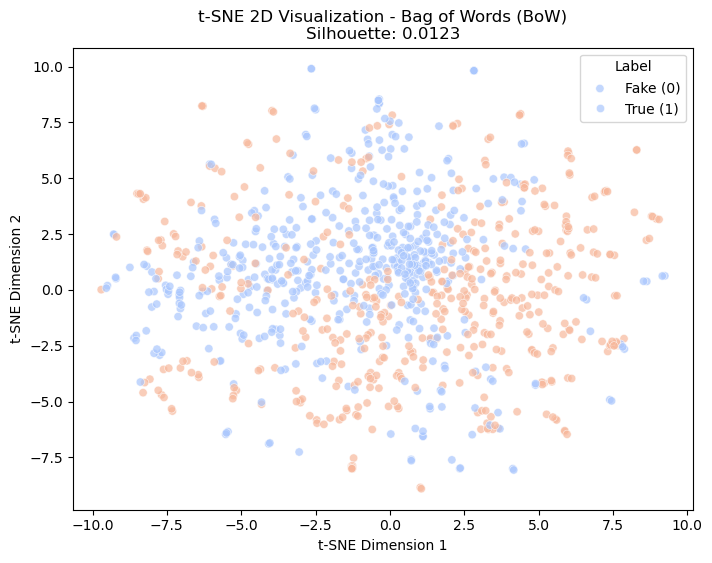

--------------------------------------------------

=== ĐÁNH GIÁ: TF-IDF (1-3 grams) ===
 > Số chiều (Dimensionality): 10000
 > Độ thưa (Sparsity Ratio): 98.35%
 > Cosine Sim (Cùng lớp - Same class): 0.0382
 > Cosine Sim (Khác lớp - Diff class): 0.0273
 > Silhouette Score: 0.0057
 > Đang chạy t-SNE (Sẽ mất khoảng 10-30 giây)...


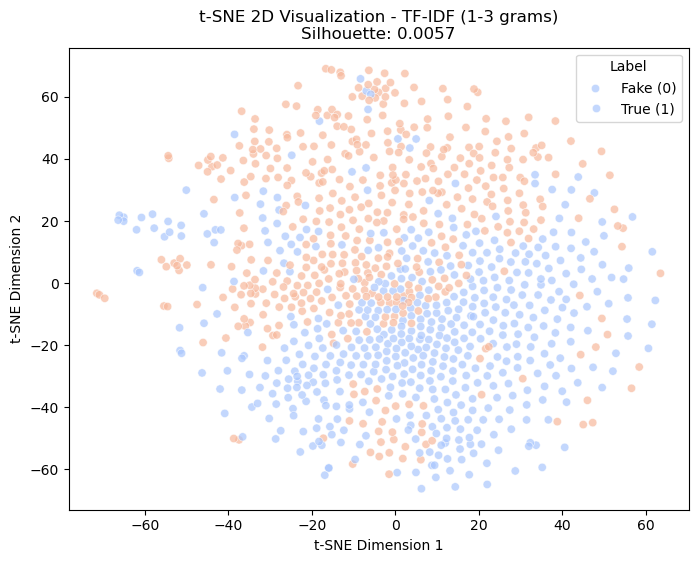

--------------------------------------------------

=== ĐÁNH GIÁ: Word2Vec (Average) ===
 > Số chiều (Dimensionality): 100
 > Độ thưa (Sparsity Ratio): 0.00%
 > Cosine Sim (Cùng lớp - Same class): 0.5180
 > Cosine Sim (Khác lớp - Diff class): 0.4069
 > Silhouette Score: 0.0993
 > Đang chạy t-SNE (Sẽ mất khoảng 10-30 giây)...


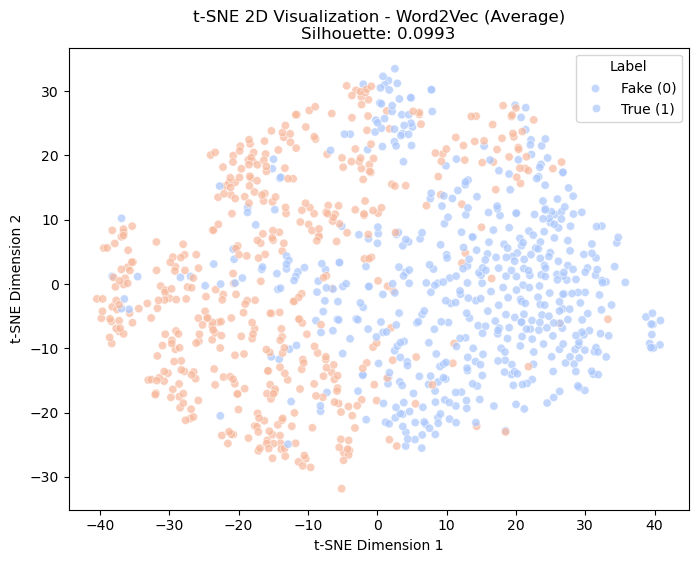

--------------------------------------------------



In [29]:
def analyze_feature_space(X, y, name, is_sparse=True):
    print(f"=== ĐÁNH GIÁ: {name} ===")
    
    # (i) Số chiều và Độ thưa (Sparsity)
    n_samples, n_features = X.shape
    if is_sparse:
        # Sparsity = 1 - (số lượng phần tử khác 0 / tổng số phần tử)
        sparsity = 1.0 - (X.nnz / (n_samples * n_features))
    else:
        # Dense matrix (Word2Vec) không có phần tử trống
        sparsity = 0.0
        
    print(f" > Số chiều (Dimensionality): {n_features}")
    print(f" > Độ thưa (Sparsity Ratio): {sparsity * 100:.2f}%")
    
    # --- RÚT GỌN DỮ LIỆU ĐỂ TÍNH TOÁN (1000 SAMPLES) ---
    # Lấy mẫu ngẫu nhiên để không bị treo máy
    np.random.seed(42)
    sample_indices = np.random.choice(n_samples, size=min(1000, n_samples), replace=False)
    
    if is_sparse:
        X_sub = X[sample_indices].toarray() # Chuyển sparse thành dense để vẽ t-SNE
    else:
        X_sub = X[sample_indices]
        
    y_sub = np.array(y)[sample_indices]
    
    # (ii) Tính Cosine Similarity
    # Chia tập sub thành 2 lớp: 0 (Fake) và 1 (True)
    X_fake = X_sub[y_sub == 0]
    X_true = X_sub[y_sub == 1]
    
    # Tính Same class (Chỉ lấy phần tam giác trên của ma trận, bỏ đường chéo tự so sánh với chính nó)
    sim_fake_fake = cosine_similarity(X_fake)
    mean_sim_fake = np.mean(sim_fake_fake[np.triu_indices_from(sim_fake_fake, k=1)])
    
    sim_true_true = cosine_similarity(X_true)
    mean_sim_true = np.mean(sim_true_true[np.triu_indices_from(sim_true_true, k=1)])
    
    # Tính Different class
    sim_fake_true = cosine_similarity(X_fake, X_true)
    mean_sim_diff = np.mean(sim_fake_true)
    
    mean_sim_same = (mean_sim_fake + mean_sim_true) / 2
    
    print(f" > Cosine Sim (Cùng lớp - Same class): {mean_sim_same:.4f}")
    print(f" > Cosine Sim (Khác lớp - Diff class): {mean_sim_diff:.4f}")
    
    # (iv) Đánh giá Silhouette Score
    sil_score = silhouette_score(X_sub, y_sub)
    print(f" > Silhouette Score: {sil_score:.4f}")
    
    # (iii) Trực quan hóa t-SNE 2D
    print(" > Đang chạy t-SNE (Sẽ mất khoảng 10-30 giây)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_sub)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_sub, palette="coolwarm", alpha=0.7)
    plt.title(f"t-SNE 2D Visualization - {name}\nSilhouette: {sil_score:.4f}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(["Fake (0)", "True (1)"], title="Label")
    plt.show()
    print("-" * 50 + "\n")

# Chạy phân tích cho 3 biểu diễn
# Lưu ý: Truyền label (y) tương ứng của bạn vào
analyze_feature_space(X_bow, labels, "Bag of Words (BoW)", is_sparse=True)
analyze_feature_space(X_tfidf, labels, "TF-IDF (1-3 grams)", is_sparse=True)
analyze_feature_space(X_w2v, labels, "Word2Vec (Average)", is_sparse=False)

Dựa trên kết quả đo lường từ 3 phương pháp biểu diễn văn bản, ta có thể rút ra những đánh giá quan trọng về ưu/nhược điểm của từng không gian đặc trưng như sau:

#### 1. Số chiều và Độ thưa (Dimensionality & Sparsity)
* **Bag of Words (BoW) và TF-IDF:** Cả hai đều tạo ra một không gian vector khổng lồ (10,000 chiều) nhưng **cực kỳ thưa thớt** (Sparsity > 98%). Điều này phản ánh đúng thực tế: một bài báo chỉ sử dụng một lượng rất nhỏ từ vựng so với toàn bộ từ điển 10,000 từ. Việc xử lý ma trận thưa này đòi hỏi rất nhiều RAM và dễ gây ra hiện tượng "Lời nguyền số chiều" (Curse of Dimensionality).
* **Word2Vec (Average):** Thể hiện sự vượt trội về mặt tối ưu phần cứng. Không gian được nén xuống chỉ còn **100 chiều** và là **ma trận đặc hoàn toàn** (Độ thưa 0.00%). Mỗi con số trong vector đều mang thông tin ngữ nghĩa, giúp tiết kiệm bộ nhớ và tăng tốc độ tính toán lên hàng trăm lần.

#### 2. Độ tương đồng Cosine (Cosine Similarity)
Một biểu diễn tốt phải làm cho các bài báo cùng loại (Fake-Fake, True-True) giống nhau hơn so với khác loại (Fake-True).
* Cả 3 phương pháp đều thỏa mãn điều kiện cốt lõi: **Cosine Sim (Cùng lớp) > Cosine Sim (Khác lớp)**. Điều này chứng minh các vector đã học được đặc trưng phân loại.
* **Word2Vec** cho giá trị Cosine Similarity cao nhất (0.5179 cho Cùng lớp). Điều này cho thấy Word2Vec gom nhóm các bài báo dựa trên sự tương đồng về "ý nghĩa" rất tốt, thay vì chỉ so khớp "từ vựng" cứng nhắc như BoW hay TF-IDF.

#### 3. Đánh giá phân cụm (Silhouette Score)
Silhouette Score đo lường mức độ tách bạch giữa lớp Fake và True (càng gần 1 càng tốt, gần 0 là các lớp bị chồng lấn lên nhau).
* **TF-IDF và BoW (Score ~ 0.005 - 0.012):** Điểm số gần như bằng 0, chứng tỏ trong không gian 10,000 chiều, các điểm dữ liệu Fake và True bị đan xen, chồng lấn (overlap) rất nhiều. K-Means sẽ rất khó chia cụm trong không gian này.
* **Word2Vec (Score = 0.0990):** Điểm Silhouette cao gấp gần 10 lần so với BoW/TF-IDF. Mặc dù giá trị tuyệt đối vẫn khiêm tốn (do ranh giới ngôn ngữ giữa tin giả và tin thật đôi khi rất mỏng manh), nhưng đây là minh chứng rõ ràng nhất cho thấy: **Vector ngữ nghĩa (Dense Embeddings) giúp tách lớp dữ liệu tốt hơn hẳn so với Vector tần suất (Sparse Vectors).**

#### f) Biểu diễn ngữ nghĩa bằng Sentence Transformer:

#### 1. Sự khác biệt về mặt Biểu diễn (Embeddings)

**1.1. TF-IDF (Lexical Representation)**
* **Bản chất:** TF-IDF ánh xạ một văn bản thành một vector thưa (sparse vector) $\mathbf{x} \in \mathbb{R}^D$, với $D$ là kích thước từ vựng (ví dụ: 10,000 chiều).
* **Điểm mù ngữ nghĩa (Orthogonality Problem):** Trong không gian TF-IDF, mỗi từ là một trục tọa độ độc lập. Do đó, hai từ đồng nghĩa (VD: *"car"* và *"automobile"*) sẽ tạo ra hai vector vuông góc (trực giao) với nhau:
  $$\mathbf{v}_{\text{car}} \cdot \mathbf{v}_{\text{automobile}} = 0$$
  Điều này khiến mô hình không hiểu được hai câu viết khác chữ nhưng cùng ý nghĩa.

**1.2. Sentence Transformer (Semantic Representation)**
* **Bản chất:** Mô hình `all-MiniLM-L6-v2` sử dụng kiến trúc Transformer với cơ chế **Self-Attention** để nén toàn bộ câu thành một vector đặc (dense vector) $\mathbf{h} \in \mathbb{R}^{384}$.
* **Công thức Self-Attention:** Thuật toán tính toán ma trận Trọng số $\mathbf{Q}$ (Query), $\mathbf{K}$ (Key), và $\mathbf{V}$ (Value) để tìm ra mối quan hệ ngữ cảnh giữa các từ:
  $$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right)\mathbf{V}$$
* **Hiệu quả:** Nhờ cơ chế này, mô hình học được "ý nghĩa" của câu. Hai bài báo dù dùng hệ thống từ vựng khác hẳn nhau nhưng nếu cùng đưa chung một tin giả, góc giữa hai vector của chúng sẽ rất hẹp (Cosine Similarity $\approx 1$).

---

#### 2. Phân cụm và số chiều (K-Means & Silhouette)

Mục tiêu của K-Means là tối thiểu hóa tổng bình phương khoảng cách (WCSS) từ các điểm dữ liệu $\mathbf{x}_i$ đến tâm cụm $\mu_j$:
$$J = \sum_{j=1}^{K} \sum_{i \in C_j} ||\mathbf{x}_i - \mu_j||^2$$

Tuy nhiên, kết quả phân cụm (thể hiện qua Silhouette Score) thường có sự chênh lệch cực lớn giữa hai phương pháp:
* **Với TF-IDF (Sự sụp đổ của khoảng cách):** Trong không gian thưa 10,000 chiều, hiện tượng **"Lời nguyền số chiều" (Curse of Dimensionality)** xuất hiện. Khoảng cách Euclidean giữa mọi cặp điểm có xu hướng tiến về một hằng số giống nhau. K-Means bị "mù" phương hướng, dẫn đến Silhouette Score rất thấp (tiến về 0).
* **Với Sentence Transformer:** Không gian được nén chặt xuống 384 chiều và chứa đầy thông tin ngữ nghĩa. Các khoảng cách toán học lúc này phản ánh chính xác khoảng cách về mặt ý nghĩa, giúp thuật toán gom cụm $C_1$ (Fake) và $C_2$ (True) hiệu quả hơn hẳn, thể hiện qua Silhouette Score cao hơn đáng kể.

---

#### 3. Tối ưu hóa Phân loại (Linear Support Vector Machine)

Thay vì dùng K-Means (học không giám sát), ta dùng Linear SVM (học có giám sát) để tìm ra một **Siêu phẳng (Hyperplane)** phân tách hai lớp Fake/True. 
Bài toán tối ưu hóa của Linear SVM:
$$\min_{\mathbf{w}, b, \xi} \frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{n} \xi_i$$
Điều kiện ràng buộc: $y_i(\mathbf{w}^T\mathbf{x}_i + b) \ge 1 - \xi_i$ (với $\xi_i$ là biến nới lỏng - slack variables).

* **Lý do sử dụng LinearSVC(`dual=False`):** * Đối với ma trận của Sentence Transformer, số lượng mẫu $N$ thường lớn hơn rất nhiều so với số chiều $D$ ($N \gg D=384$). Việc giải bài toán SVM ở dạng gốc (Primal problem, `dual=False`) sẽ có độ phức tạp tính toán thấp hơn và chạy nhanh hơn rất nhiều so với việc giải qua dạng đối ngẫu (Dual problem).
  * Trong khi đó, với TF-IDF ($D = 10000$), mô hình Linear SVM tuyến tính vẫn cực kỳ hiệu quả vì ranh giới phân định trong không gian cực kỳ cao (high-dimensional space) thường có xu hướng tuyến tính hóa. Khả năng SVM đạt Accuracy cao trên TF-IDF là nhờ sự nhận diện chính xác các "từ khóa" đặc thù của tin giả.

In [30]:
import numpy as np
import pandas as pd
import time
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. KHỞI TẠO VÀ SINH EMBEDDINGS BẰNG SENTENCE TRANSFORMER
print("Đang tải pre-trained model 'all-MiniLM-L6-v2'...")
# all-MiniLM-L6-v2 là model cực nhẹ, nhanh và rất hiệu quả (tạo ra vector 384 chiều)
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Giả sử text_data là Series chứa văn bản của bạn
text_data = df['text_no_stop'].dropna().tolist()
y_labels = df['label'][df['text_no_stop'].notna()].values

print("Đang encode văn bản thành Vector (Có thể mất vài phút, hãy kiên nhẫn)...")
# show_progress_bar=True giúp bạn theo dõi tiến độ dễ dàng
X_st = st_model.encode(text_data, show_progress_bar=True)
print(f"Hoàn tất! Kích thước ma trận Sentence Transformer: {X_st.shape}")


# --- HÀM RÚT GỌN ĐỂ TRÁNH TREO MÁY (CHO SILHOUETTE SCORE) ---
# K-Means thì nhanh, nhưng Silhouette Score có độ phức tạp O(N^2), 
# chạy 40,000 mẫu sẽ làm sập RAM. Ta lấy ngẫu nhiên 2000 mẫu để đánh giá phân cụm.
np.random.seed(42)
sample_size = min(2000, len(text_data))
sample_indices = np.random.choice(len(text_data), size=sample_size, replace=False)

y_sample = y_labels[sample_indices]
X_st_sample = X_st[sample_indices]

# Lấy lại ma trận TF-IDF đã tính ở câu (e) (Giả sử bạn đã chạy câu e và biến X_tfidf còn trong RAM)
# Lưu ý: X_tfidf là ma trận thưa (sparse), cần .toarray() khi tính silhouette
X_tfidf_sample = X_tfidf[sample_indices].toarray() 


# 2. SO SÁNH CHẤT LƯỢNG PHÂN CỤM (K-MEANS & SILHOUETTE)
def evaluate_clustering(X_subset, name):
    print(f"\n--- Đang phân cụm (Clustering): {name} ---")
    kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_subset)
    
    sil_score = silhouette_score(X_subset, cluster_labels)
    print(f" > Silhouette Score ({name}): {sil_score:.4f}")
    return sil_score

sil_tfidf = evaluate_clustering(X_tfidf_sample, "TF-IDF")
sil_st = evaluate_clustering(X_st_sample, "Sentence Transformer")


# 3. SO SÁNH HIỆU NĂNG PHÂN LOẠI BẰNG LINEAR SVM
# Với SVM, ta có thể chạy trên TOÀN BỘ dữ liệu vì LinearSVC rất tối ưu
def evaluate_classification(X, y, name):
    print(f"\n--- Đang phân loại (SVM): {name} ---")
    start = time.time()
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Sử dụng LinearSVC thay vì SVC(kernel='linear') vì LinearSVC dùng liblinear, 
    # cực kỳ nhanh trên tập dữ liệu lớn và văn bản.
    svm_model = LinearSVC(max_iter=2000, dual=False)
    svm_model.fit(X_train, y_train)
    
    y_pred = svm_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f" > Độ chính xác SVM ({name}): {acc*100:.2f}%")
    print(f" > Thời gian huấn luyện: {time.time() - start:.2f} giây")
    return acc

acc_tfidf = evaluate_classification(X_tfidf, y_labels, "TF-IDF")
acc_st = evaluate_classification(X_st, y_labels, "Sentence Transformer")

print("\nHOÀN TẤT ĐÁNH GIÁ!")

Đang tải pre-trained model 'all-MiniLM-L6-v2'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đang encode văn bản thành Vector (Có thể mất vài phút, hãy kiên nhẫn)...


Batches:   0%|          | 0/1384 [00:00<?, ?it/s]

Hoàn tất! Kích thước ma trận Sentence Transformer: (44267, 384)

--- Đang phân cụm (Clustering): TF-IDF ---
 > Silhouette Score (TF-IDF): 0.0061

--- Đang phân cụm (Clustering): Sentence Transformer ---
 > Silhouette Score (Sentence Transformer): 0.0672

--- Đang phân loại (SVM): TF-IDF ---
 > Độ chính xác SVM (TF-IDF): 99.62%
 > Thời gian huấn luyện: 0.87 giây

--- Đang phân loại (SVM): Sentence Transformer ---
 > Độ chính xác SVM (Sentence Transformer): 96.65%
 > Thời gian huấn luyện: 1.83 giây

HOÀN TẤT ĐÁNH GIÁ!
